 # LLM-as-a-Judge Evaluation for NIS2 Compliance Reports

 This notebook implements the evaluation methodology described in Section 4.8
 of the thesis. It uses a multi-judge panel (Claude, GPT, Gemini) to score
 generated compliance reports on four dimensions, following the PoLL approach
 (Verga et al., 2024) and the LLM-as-a-Judge paradigm (Zheng et al., 2023).

In [ ]:
# ============================================================================
# 0. Configuration and Imports
# ============================================================================

import json
import os
import re
import time
import warnings
from pathlib import Path
from collections import defaultdict
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 150

EVAL_OUTS_DIR = Path("../out/eval_outs")       # contains ChatGPT/, Ollama/, Qwen/
EVAL_LOGS_PATH = Path("../out/eval_logs/eval_log.jsonl")
RESULTS_DIR = Path("../out/judge_results")

# Map folder names to the model identifiers used in eval_log.jsonl
FOLDER_TO_MODEL = {
    "ChatGPT": ("EXTERNAL", "gpt-5.4-nano"),
    "Ollama":  ("LOCAL",    "llama3.1:8b"),
    "Qwen":    ("EXTERNAL", "Qwen/Qwen3-32B-TEE"),
}

print("Configuration loaded.")
print(f"  eval_outs dir: {EVAL_OUTS_DIR.resolve()}")
print(f"  eval_logs:     {EVAL_LOGS_PATH.resolve()}")
print(f"  results dir:   {RESULTS_DIR.resolve()}")

Configuration loaded.
  eval_outs dir: D:\User Files\ProgFiles\python\cybersec-compliance\out\eval_outs
  eval_logs:     D:\User Files\ProgFiles\python\cybersec-compliance\out\eval_logs\eval_log.jsonl
  results dir:   D:\User Files\ProgFiles\python\cybersec-compliance\out\judge_results


In [ ]:
def load_reports(eval_outs_dir: Path) -> pd.DataFrame:
    """Load all .md reports from eval_outs/{model}/ folders."""
    rows = []
    for folder_name, (provider, model) in FOLDER_TO_MODEL.items():
        folder = eval_outs_dir / folder_name
        if not folder.exists():
            print(f"  WARNING: {folder} does not exist, skipping.")
            continue
        md_files = sorted(folder.glob("*.md"))
        print(f"  {folder_name}: found {len(md_files)} reports")
        for f in md_files:
            text = f.read_text(encoding="utf-8", errors="replace")
            # Parse run number and period from filename
            # e.g. "1_access_control_report_2019-11-07T00..." or "..._unknown.md"
            fname = f.stem
            parts = fname.split("_access_control_report_")
            run_num = parts[0] if len(parts) > 1 else "1"
            period_str = parts[1] if len(parts) > 1 else fname
            
            rows.append({
                "folder": folder_name,
                "provider": provider,
                "model": model,
                "filename": f.name,
                "run_number": run_num,
                "period": period_str,
                "report_text": text,
                "report_length": len(text),
            })
    
    df = pd.DataFrame(rows)
    print(f"\nTotal reports loaded: {len(df)}")
    print(f"By model: {df.groupby('folder').size().to_dict()}")
    return df

reports_df = load_reports(EVAL_OUTS_DIR)
if len(reports_df) > 0:
    print(f"\nSample filenames:")
    for f in reports_df["filename"].head(5):
        print(f"  {f}")

  ChatGPT: found 35 reports
  Ollama: found 35 reports
  Qwen: found 35 reports

Total reports loaded: 105
By model: {'ChatGPT': 35, 'Ollama': 35, 'Qwen': 35}

Sample filenames:
  1_access_control_report_2019-11-07T00-00-00.md
  1_access_control_report_2020-02-05T00-00-00.md
  1_access_control_report_2020-05-05T00-00-00.md
  1_access_control_report_2020-08-03T00-00-00.md
  1_access_control_report_2020-11-01T00-00-00.md


In [ ]:
JUDGE_SYSTEM_PROMPT = """You are an expert cybersecurity compliance auditor evaluating AI-generated NIS2 compliance reports. You will score each report on a specific evaluation dimension using a 1-5 Likert scale. 

Be rigorous and precise. Base your scores strictly on the evidence in the report text. Do not give the benefit of the doubt — if something is vague or missing, score accordingly."""

RUBRIC_PROMPTS = {
    "regulatory_accuracy": """## Evaluation Dimension: Regulatory Accuracy

Score how accurately the report cites NIS2 articles, obligations, and requirements.

**Score 1:** Contains multiple factual errors about NIS2, cites wrong article numbers, or fabricates requirements that do not exist in the directive.
**Score 2:** Contains at least one significant factual error about NIS2 provisions, or attributes obligations to wrong articles.
**Score 3:** Generally correct but includes vague or imprecise references to NIS2 (e.g., "NIS2 requires..." without specifying which article).
**Score 4:** All NIS2 references are correct with minor imprecisions in scope or phrasing.
**Score 5:** All cited NIS2 articles, obligations, and requirements are factually correct and properly attributed to specific articles/clauses.

Respond with ONLY a JSON object in this exact format:
{"score": <1-5>, "justification": "<2-3 sentences explaining your score>"}""",

    "completeness": """## Evaluation Dimension: Completeness

Score how well the report covers the relevant NIS2 Article 21(2) requirements for access control.

NIS2 Article 21(2) specifies these mandatory cybersecurity measures. For an access control report, the most relevant are:
- (a) policies on risk analysis and information system security
- (b) incident handling
- (d) supply chain security (if relevant)
- (i) human resources security, access control policies, and asset management
- (j) use of multi-factor authentication (MFA) and continuous authentication solutions

**Score 1:** Covers fewer than 2 of the relevant mandatory measures.
**Score 2:** Covers 2-3 measures but with significant gaps.
**Score 3:** Covers most relevant measures (4+) but some are treated superficially.
**Score 4:** Covers all relevant measures with reasonable depth.
**Score 5:** Comprehensively covers all relevant measures with specific findings, evidence, and recommendations for each.

Respond with ONLY a JSON object in this exact format:
{"score": <1-5>, "justification": "<2-3 sentences explaining your score>"}""",

    "faithfulness": """## Evaluation Dimension: Faithfulness to Evidence

Score whether the report's claims appear grounded in actual data (metrics, log analysis) rather than being generic or fabricated.

**Score 1:** Majority of claims are generic statements with no reference to specific data. Appears to be template text rather than data-driven analysis.
**Score 2:** Some claims reference data but many are unsupported generalisations.
**Score 3:** Most claims reference metrics or data, but some findings lack clear evidence linkage.
**Score 4:** Nearly all claims are tied to specific metrics or evidence. Minor instances of vague language.
**Score 5:** Every claim is explicitly grounded in computed metrics, log data, or retrieved regulatory text. All numbers are specific and traceable.

Respond with ONLY a JSON object in this exact format:
{"score": <1-5>, "justification": "<2-3 sentences explaining your score>"}""",

    "actionability": """## Evaluation Dimension: Actionability

Score whether the report's recommendations are specific and implementable.

**Score 1:** Recommendations are entirely generic platitudes (e.g., "improve security posture", "implement best practices") with no specifics.
**Score 2:** Some recommendations name specific areas but lack concrete steps or timelines.
**Score 3:** Recommendations identify specific controls or actions but lack implementation detail or prioritisation.
**Score 4:** Recommendations are specific, reference concrete controls or standards, and include some prioritisation.
**Score 5:** Recommendations reference specific controls, include implementation steps, suggest timelines or priorities, and are clearly tied to the findings they address.

Respond with ONLY a JSON object in this exact format:
{"score": <1-5>, "justification": "<2-3 sentences explaining your score>"}""",
}

print(f"Defined {len(RUBRIC_PROMPTS)} evaluation dimensions:")
for dim in RUBRIC_PROMPTS:
    print(f"  - {dim}")

Defined 4 evaluation dimensions:
  - regulatory_accuracy
  - completeness
  - faithfulness
  - actionability


In [ ]:

# Stratified Sampling (optional — reduces cost and runtime)

# With 35 reports per model (105 total), a full evaluation run takes ~70 min
# and costs ~$15-25. Sampling 10-12 per model gives strong statistical power
# while cutting cost by ~2/3.
#
# Set SAMPLE_PER_MODEL = None to evaluate ALL reports.

SAMPLE_PER_MODEL = 12

def stratified_sample(df: pd.DataFrame, n_per_model: int, seed: int = 42) -> pd.DataFrame:
    """Sample n reports per model, balanced across time periods.
    
    Strategy: within each model folder, group by period and sample
    proportionally so every period is represented. If a period has
    fewer reports than its share, take all of them and redistribute
    the remaining slots to other periods.
    """
    rng = np.random.RandomState(seed)
    sampled = []
    
    for folder, group in df.groupby("folder"):
        periods = group["period"].unique()
        n_periods = len(periods)
        
        if len(group) <= n_per_model:
            # Fewer reports than requested — take all
            sampled.append(group)
            print(f"  {folder}: taking all {len(group)} reports ({n_periods} periods)")
            continue
        
        # Allocate slots proportionally across periods
        base_per_period = n_per_model // n_periods
        remainder = n_per_model % n_periods
        
        folder_sample = []
        leftover_budget = 0
        
        for i, period in enumerate(sorted(periods)):
            period_reports = group[group["period"] == period]
            # Give one extra to the first `remainder` periods
            target = base_per_period + (1 if i < remainder else 0)
            
            if len(period_reports) <= target:
                folder_sample.append(period_reports)
                leftover_budget += target - len(period_reports)
            else:
                folder_sample.append(period_reports.sample(n=target, random_state=rng))
        
        result = pd.concat(folder_sample, ignore_index=True)
        
        # If we have leftover budget (some periods had fewer reports), fill from remaining
        if leftover_budget > 0:
            already_selected = set(result["filename"])
            remaining = group[~group["filename"].isin(already_selected)]
            if len(remaining) > 0:
                extra = remaining.sample(n=min(leftover_budget, len(remaining)), random_state=rng)
                result = pd.concat([result, extra], ignore_index=True)
        
        print(f"  {folder}: sampled {len(result)}/{len(group)} reports across {n_periods} periods")
        sampled.append(result)
    
    final = pd.concat(sampled, ignore_index=True)
    return final


if SAMPLE_PER_MODEL is not None and len(reports_df) > 0:
    print(f"Sampling {SAMPLE_PER_MODEL} reports per model (stratified by period):")
    reports_df_eval = stratified_sample(reports_df, SAMPLE_PER_MODEL)
    print(f"\nEvaluation set: {len(reports_df_eval)} reports")
    print(f"Distribution: {reports_df_eval.groupby('folder').size().to_dict()}")
    
    n_calls = len(reports_df_eval) * len(RUBRIC_PROMPTS) * 3  # assuming 3 judges
    print(f"Estimated API calls: {n_calls} (rubric) + {len(reports_df_eval)} (coverage) = {n_calls + len(reports_df_eval)}")
    print(f"Estimated time: ~{(n_calls + len(reports_df_eval)) * 3 / 60:.0f} minutes")
else:
    reports_df_eval = reports_df
    print(f"Using ALL {len(reports_df_eval)} reports (no sampling)")

Sampling 12 reports per model (stratified by period):
  ChatGPT: sampled 12/35 reports across 7 periods
  Ollama: sampled 12/35 reports across 7 periods
  Qwen: sampled 12/35 reports across 7 periods

Evaluation set: 36 reports
Distribution: {'ChatGPT': 12, 'Ollama': 12, 'Qwen': 12}
Estimated API calls: 432 (rubric) + 36 (coverage) = 468
Estimated time: ~23 minutes


In [ ]:
# Load Input Metrics from Eval Logs (for faithfulness checking)

def load_eval_logs(path: Path) -> Dict[str, Dict]:
    """Load eval logs and index by (provider, model, period) for metric lookup."""
    if not path.exists():
        print(f"WARNING: {path} not found. Faithfulness checks will be limited.")
        return {}
    
    entries = []
    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            try:
                entries.append(json.loads(line))
            except json.JSONDecodeError:
                pass
    
    # Index by (provider, model, period) -> first matching metrics_input
    metrics_by_key = {}
    for e in entries:
        key = (e.get("provider", ""), e.get("model", ""), e.get("period", ""))
        if key not in metrics_by_key:
            # Try to extract the metrics input that was passed to the LLM
            mi = e.get("metrics_input") or e.get("input_metrics") or {}
            if mi:
                metrics_by_key[key] = mi
    
    print(f"Loaded metrics for {len(metrics_by_key)} unique (provider, model, period) combos")
    return metrics_by_key

eval_metrics = load_eval_logs(EVAL_LOGS_PATH)

Loaded metrics for 21 unique (provider, model, period) combos


In [ ]:

# Judge API Wrappers

def call_anthropic(system: str, user: str, model: str = "claude-sonnet-4-6") -> str:
    """Call the Anthropic API."""
    import anthropic
    client = anthropic.Anthropic()
    response = client.messages.create(
        model=model,
        max_tokens=300,
        temperature=0,
        system=system,
        messages=[{"role": "user", "content": user}],
    )
    return response.content[0].text


def call_openai(system: str, user: str, model: str = "gpt-5.4") -> str:
    """Call the OpenAI API."""
    from openai import OpenAI
    client = OpenAI()
    response = client.chat.completions.create(
        model=model,
        temperature=0,
        max_completion_tokens=300,
        messages=[
            {"role": "system", "content": system},
            {"role": "user", "content": user},
        ],
    )
    return response.choices[0].message.content


JUDGE_FUNCTIONS = {
    "Claude": call_anthropic,
    "GPT": call_openai,
}

# Map which judge is "biased" for which model folder (produced by the same vendor)
# Used in Section 6 to compute bias-adjusted scores
SELF_JUDGE_MAP = {
    # folder_name -> judge_name that might be biased (same vendor)
    "ChatGPT": "GPT",      # GPT judging its own outputs
    "Ollama":  None,        # Neither judge produced LLaMA outputs
    "Qwen":    None,        # Neither judge produced Qwen outputs
}

# Test which judges are available
available_judges = {}
for judge_name, judge_fn in JUDGE_FUNCTIONS.items():
    try:
        result = judge_fn("You are a test.", "Reply with: {\"status\": \"ok\"}")
        available_judges[judge_name] = judge_fn
        print(f"  {judge_name}: AVAILABLE")
    except Exception as e:
        print(f"  {judge_name}: UNAVAILABLE ({type(e).__name__}: {e})")

print(f"\n{len(available_judges)} judge(s) available: {list(available_judges.keys())}")

  Claude: AVAILABLE
  GPT: AVAILABLE

2 judge(s) available: ['Claude', 'GPT']


In [ ]:
# Run the Multi-Judge Evaluation

def parse_judge_response(raw: str) -> Tuple[Optional[int], str]:
    """Extract score and justification from judge response."""
    # Try to parse as JSON
    try:
        # Handle markdown code fences
        cleaned = re.sub(r"```json\s*", "", raw)
        cleaned = re.sub(r"```\s*", "", cleaned)
        cleaned = cleaned.strip()
        data = json.loads(cleaned)
        score = int(data.get("score", 0))
        justification = data.get("justification", "")
        if 1 <= score <= 5:
            return score, justification
    except (json.JSONDecodeError, ValueError, TypeError):
        pass
    
    # Fallback: try to extract score from text
    match = re.search(r'"score"\s*:\s*(\d)', raw)
    if match:
        score = int(match.group(1))
        if 1 <= score <= 5:
            return score, raw
    
    return None, f"PARSE_FAILED: {raw[:200]}"


def evaluate_reports(
    reports_df: pd.DataFrame,
    judges: Dict[str, callable],
    dimensions: Dict[str, str],
    system_prompt: str,
    max_reports: Optional[int] = None,
    delay_seconds: float = 1.0,
) -> pd.DataFrame:
    """Run all judges on all reports for all dimensions."""
    
    results = []
    df_to_eval = reports_df if max_reports is None else reports_df.head(max_reports)
    total = len(df_to_eval) * len(dimensions) * len(judges)
    current = 0
    
    for idx, row in df_to_eval.iterrows():
        report_text = row["report_text"]
        # Truncate very long reports to avoid token limits
        if len(report_text) > 15000:
            report_text = report_text[:7500] + "\n\n[... truncated ...]\n\n" + report_text[-7500:]
        
        for dim_name, dim_prompt in dimensions.items():
            user_prompt = f"""{dim_prompt}

## Report to Evaluate

Source Model: {row['folder']}
Period: {row['period']}

<report>
{report_text}
</report>"""
            
            for judge_name, judge_fn in judges.items():
                current += 1
                print(f"  [{current}/{total}] {row['folder']}/{row['filename'][:30]}... | {dim_name} | Judge: {judge_name}", end="")
                
                try:
                    raw_response = judge_fn(system_prompt, user_prompt)
                    score, justification = parse_judge_response(raw_response)
                    print(f" -> Score: {score}")
                except Exception as e:
                    score = None
                    justification = f"API_ERROR: {e}"
                    raw_response = str(e)
                    print(f" -> ERROR: {e}")
                
                results.append({
                    "folder": row["folder"],
                    "provider": row["provider"],
                    "model": row["model"],
                    "filename": row["filename"],
                    "period": row["period"],
                    "run_number": row["run_number"],
                    "dimension": dim_name,
                    "judge": judge_name,
                    "score": score,
                    "justification": justification,
                    "raw_response": raw_response,
                })
                
                time.sleep(delay_seconds)
    
    return pd.DataFrame(results)


# --- Run the evaluation ---
# To test with a small subset first, set max_reports=3
# For the full evaluation, set max_reports=None

if len(available_judges) > 0 and len(reports_df_eval) > 0:
    print(f"\nStarting evaluation: {len(reports_df_eval)} reports × {len(RUBRIC_PROMPTS)} dimensions × {len(available_judges)} judges")
    print(f"Total API calls: {len(reports_df_eval) * len(RUBRIC_PROMPTS) * len(available_judges)}")
    print(f"Estimated time: ~{len(reports_df_eval) * len(RUBRIC_PROMPTS) * len(available_judges) * 3 / 60:.0f} minutes\n")
    
    judge_results = evaluate_reports(
        reports_df_eval,
        available_judges,
        RUBRIC_PROMPTS,
        JUDGE_SYSTEM_PROMPT,
        max_reports=None,  # Change to 3 for a quick test run
        delay_seconds=1.5,
    )
    
    # Save intermediate results
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    judge_results.to_csv(RESULTS_DIR / "judge_results_raw.csv", index=False)
    print(f"\nRaw results saved to {RESULTS_DIR / 'judge_results_raw.csv'}")
else:
    print("Cannot run evaluation: no judges available or no reports loaded.")
    print("Set API keys and check EVAL_OUTS_DIR path.")
    judge_results = pd.DataFrame()


Starting evaluation: 36 reports × 4 dimensions × 2 judges
Total API calls: 288
Estimated time: ~14 minutes

  [1/288] ChatGPT/2_access_control_report_2019-1... | regulatory_accuracy | Judge: Claude -> Score: 4
  [2/288] ChatGPT/2_access_control_report_2019-1... | regulatory_accuracy | Judge: GPT -> Score: 2
  [3/288] ChatGPT/2_access_control_report_2019-1... | completeness | Judge: Claude -> Score: 3
  [4/288] ChatGPT/2_access_control_report_2019-1... | completeness | Judge: GPT -> Score: 2
  [5/288] ChatGPT/2_access_control_report_2019-1... | faithfulness | Judge: Claude -> Score: 5
  [6/288] ChatGPT/2_access_control_report_2019-1... | faithfulness | Judge: GPT -> Score: 4
  [7/288] ChatGPT/2_access_control_report_2019-1... | actionability | Judge: Claude -> Score: 4
  [8/288] ChatGPT/2_access_control_report_2019-1... | actionability | Judge: GPT -> Score: 4
  [9/288] ChatGPT/5_access_control_report_2019-1... | regulatory_accuracy | Judge: Claude -> Score: 4
  [10/288] ChatGPT/5_acce

In [ ]:
# Analyse Judge Results

def analyse_judge_results(results_df: pd.DataFrame) -> None:
    """Produce summary tables and plots from judge results."""
    
    if len(results_df) == 0:
        print("No results to analyse.")
        return
    
    # Filter out failed parses
    valid = results_df[results_df["score"].notna()].copy()
    valid["score"] = valid["score"].astype(int)
    failed = len(results_df) - len(valid)
    if failed > 0:
        print(f"WARNING: {failed} evaluations failed to parse ({failed/len(results_df)*100:.1f}%)")
    
    # Raw mean scores by model and dimension (averaged across judges)
    print("\n" + "="*80)
    print("RAW MEAN SCORES BY MODEL AND DIMENSION (averaged across all judges)")
    print("="*80)
    
    pivot = valid.groupby(["folder", "dimension"])["score"].mean().unstack()
    pivot["OVERALL"] = pivot.mean(axis=1)
    pivot = pivot.round(2)
    print(pivot.to_string())
    
    # Per-judge scores (to detect self-enhancement bias)
    print("\n" + "="*80)
    print("SCORES BY JUDGE × MODEL (detect self-enhancement bias)")
    print("="*80)
    
    judge_model = valid.groupby(["judge", "folder"])["score"].mean().unstack().round(2)
    print(judge_model.to_string())
    
    # Flag self-enhancement
    print("\n  Self-enhancement check:")
    for folder, biased_judge in SELF_JUDGE_MAP.items():
        if biased_judge is None:
            print(f"    {folder}: no self-judge (neutral)")
            continue
        if biased_judge not in judge_model.index or folder not in judge_model.columns:
            continue
        self_score = judge_model.loc[biased_judge, folder]
        other_judges = [j for j in judge_model.index if j != biased_judge]
        if other_judges:
            cross_score = judge_model.loc[other_judges, folder].mean()
            delta = self_score - cross_score
            flag = " *** BIAS DETECTED" if delta > 0.3 else ""
            print(f"    {folder}: {biased_judge} (self) = {self_score:.2f}, cross-judge = {cross_score:.2f}, Δ = {delta:+.2f}{flag}")
    
    # BIAS-ADJUSTED scores (primary metric for the paper)
    print("\n" + "="*80)
    print("BIAS-ADJUSTED SCORES (excluding self-judge where applicable)")
    print("="*80)
    print("  For ChatGPT reports: uses only Claude's scores")
    print("  For Ollama/Qwen reports: uses both judges (neither is biased)\n")
    
    adjusted_rows = []
    for folder in valid["folder"].unique():
        biased_judge = SELF_JUDGE_MAP.get(folder)
        folder_data = valid[valid["folder"] == folder]
        
        if biased_judge:
            # Exclude the self-judge
            folder_data = folder_data[folder_data["judge"] != biased_judge]
        
        for dim in valid["dimension"].unique():
            dim_scores = folder_data[folder_data["dimension"] == dim]["score"]
            if len(dim_scores) > 0:
                adjusted_rows.append({
                    "folder": folder,
                    "dimension": dim,
                    "mean_score": dim_scores.mean(),
                    "std_score": dim_scores.std(),
                    "n": len(dim_scores),
                    "judges_used": ", ".join(folder_data["judge"].unique()),
                })
    
    adjusted_df = pd.DataFrame(adjusted_rows)
    adj_pivot = adjusted_df.pivot(index="folder", columns="dimension", values="mean_score").round(2)
    adj_pivot["OVERALL"] = adj_pivot.mean(axis=1).round(2)
    print(adj_pivot.to_string())
    
    # Inter-judge agreement (Cohen's kappa)
    print("\n" + "="*80)
    print("INTER-JUDGE AGREEMENT")
    print("="*80)
    
    judges_list = valid["judge"].unique()
    if len(judges_list) >= 2:
        from itertools import combinations
        for j1, j2 in combinations(judges_list, 2):
            merged = valid[valid["judge"] == j1][["filename", "dimension", "score"]].merge(
                valid[valid["judge"] == j2][["filename", "dimension", "score"]],
                on=["filename", "dimension"],
                suffixes=(f"_{j1}", f"_{j2}")
            )
            if len(merged) > 0:
                from sklearn.metrics import cohen_kappa_score
                kappa = cohen_kappa_score(
                    merged[f"score_{j1}"], merged[f"score_{j2}"],
                    weights="linear"
                )
                corr = merged[f"score_{j1}"].corr(merged[f"score_{j2}"])
                mean_diff = (merged[f"score_{j1}"] - merged[f"score_{j2}"]).mean()
                print(f"  {j1} vs {j2}: κ = {kappa:.3f}, r = {corr:.3f}, mean Δ = {mean_diff:+.2f} (n={len(merged)})")
    else:
        print("  Need 2+ judges for agreement analysis.")
    
    # Statistical comparison across models (using bias-adjusted scores)
    print("\n" + "="*80)
    print("STATISTICAL COMPARISON: LOCAL vs EXTERNAL (bias-adjusted)")
    print("="*80)
    
    from scipy import stats
    
    # Rebuild a flat score series with bias adjustment applied
    adjusted_scores = []
    for _, row in valid.iterrows():
        biased_judge = SELF_JUDGE_MAP.get(row["folder"])
        if biased_judge and row["judge"] == biased_judge:
            continue  # Skip self-rated scores
        adjusted_scores.append(row)
    adj_valid = pd.DataFrame(adjusted_scores)
    
    for dim in adj_valid["dimension"].unique():
        local_scores = adj_valid[(adj_valid["provider"] == "LOCAL") & (adj_valid["dimension"] == dim)]["score"]
        external_scores = adj_valid[(adj_valid["provider"] == "EXTERNAL") & (adj_valid["dimension"] == dim)]["score"]
        
        if len(local_scores) >= 3 and len(external_scores) >= 3:
            stat, pval = stats.mannwhitneyu(local_scores, external_scores, alternative="two-sided")
            pooled_std = np.sqrt(
                ((len(local_scores)-1)*local_scores.std()**2 + (len(external_scores)-1)*external_scores.std()**2) /
                (len(local_scores) + len(external_scores) - 2)
            )
            d = (local_scores.mean() - external_scores.mean()) / pooled_std if pooled_std > 0 else 0
            effect = "Large" if abs(d) > 0.8 else "Medium" if abs(d) > 0.5 else "Small" if abs(d) > 0.2 else "Negligible"
            sig = "Yes" if pval < 0.05 else "No"
            print(f"  {dim:25s} | LOCAL={local_scores.mean():.2f} EXTERNAL={external_scores.mean():.2f} | p={pval:.4f} ({sig}) | d={d:.3f} ({effect})")
    
    return adj_pivot


if len(judge_results) > 0:
    summary_pivot = analyse_judge_results(judge_results)


RAW MEAN SCORES BY MODEL AND DIMENSION (averaged across all judges)
dimension  actionability  completeness  faithfulness  regulatory_accuracy  OVERALL
folder                                                                            
ChatGPT             3.92          2.62          4.25                 3.38     3.54
Ollama              2.33          2.29          2.88                 1.88     2.34
Qwen                3.50          2.58          2.92                 2.25     2.81

SCORES BY JUDGE × MODEL (detect self-enhancement bias)
folder  ChatGPT  Ollama  Qwen
judge                        
Claude     3.90    2.52  3.06
GPT        3.19    2.17  2.56

  Self-enhancement check:
    ChatGPT: GPT (self) = 3.19, cross-judge = 3.90, Δ = -0.71
    Ollama: no self-judge (neutral)
    Qwen: no self-judge (neutral)

BIAS-ADJUSTED SCORES (excluding self-judge where applicable)
  For ChatGPT reports: uses only Claude's scores
  For Ollama/Qwen reports: uses both judges (neither is biased)

dimen

In [ ]:
# Access Control Coverage Scoring (NIS2 Art. 21(2)(i) and (j))
# ============================================================================
# The system focuses on access control, so the generic 10-measure checklist
# is meaningless (reports always score ~2/10). Instead, we evaluate coverage
# of specific access control sub-topics that a thorough report SHOULD address.

ACCESS_CONTROL_TOPICS = {
    "auth_failure_analysis":   "Analysis of authentication failure rates and patterns",
    "mfa_coverage":            "MFA adoption/coverage assessment",
    "privileged_access":       "Privileged/admin account access review",
    "account_lockout":         "Account lockout or brute-force protection policies",
    "password_policy":         "Password policy compliance or credential hygiene",
    "ip_reputation":           "Source IP reputation or geolocation risk analysis",
    "session_management":      "Session management, timeout, or concurrent login controls",
    "access_review_cadence":   "Periodic access review or recertification recommendations",
    "rbac_least_privilege":    "Role-based access control or least-privilege analysis",
    "anomaly_detection":       "Anomalous login behaviour or account takeover detection",
    "regulatory_mapping":      "Explicit mapping of findings to NIS2 articles or ISO 27001 controls",
    "trend_analysis":          "Trend analysis comparing current vs. prior periods",
}

COVERAGE_PROMPT = f"""You are a cybersecurity compliance auditor specialising in NIS2 access control requirements (Article 21(2)(i) and (j)).

Analyse the following compliance report and determine which of these access control sub-topics are substantively addressed (not just a passing mention — the report must include specific findings, data, or recommendations for the topic).

The {len(ACCESS_CONTROL_TOPICS)} topics are:
""" + "\n".join(f"- {k}: {v}" for k, v in ACCESS_CONTROL_TOPICS.items()) + """

Respond with ONLY a JSON object mapping each topic key to true/false:
{""" + ", ".join(f'"{k}": true/false' for k in ACCESS_CONTROL_TOPICS) + """, "coverage_count": <0-""" + str(len(ACCESS_CONTROL_TOPICS)) + """>}"""


def evaluate_coverage(
    reports_df: pd.DataFrame,
    judge_fn: callable,
    judge_name: str,
    max_reports: Optional[int] = None,
) -> pd.DataFrame:
    """Evaluate access control topic coverage for each report."""
    results = []
    df_to_eval = reports_df if max_reports is None else reports_df.head(max_reports)
    total = len(df_to_eval)
    
    for i, (idx, row) in enumerate(df_to_eval.iterrows(), 1):
        report_text = row["report_text"]
        if len(report_text) > 15000:
            report_text = report_text[:7500] + "\n\n[... truncated ...]\n\n" + report_text[-7500:]
        
        user_prompt = f"""<report>
{report_text}
</report>"""
        
        print(f"  [{i}/{total}] {row['folder']}/{row['filename'][:35]}...", end="")
        
        try:
            raw = judge_fn(COVERAGE_PROMPT, user_prompt)
            cleaned = re.sub(r"```json\s*", "", raw)
            cleaned = re.sub(r"```\s*", "", cleaned).strip()
            data = json.loads(cleaned)
            
            coverage_count = sum(1 for k in ACCESS_CONTROL_TOPICS if data.get(k, False))
            print(f" -> {coverage_count}/{len(ACCESS_CONTROL_TOPICS)}")
            
            result = {
                "folder": row["folder"],
                "provider": row["provider"],
                "model": row["model"],
                "filename": row["filename"],
                "period": row["period"],
                "judge": judge_name,
                "coverage_count": coverage_count,
            }
            for k in ACCESS_CONTROL_TOPICS:
                result[f"topic_{k}"] = bool(data.get(k, False))
            results.append(result)
            
        except Exception as e:
            print(f" -> ERROR: {e}")
            results.append({
                "folder": row["folder"], "provider": row["provider"],
                "model": row["model"], "filename": row["filename"],
                "period": row["period"], "judge": judge_name,
                "coverage_count": None,
            })
        
        time.sleep(1.5)
    
    return pd.DataFrame(results)


# Run coverage evaluation using the first available judge
if len(available_judges) > 0 and len(reports_df_eval) > 0:
    first_judge_name = list(available_judges.keys())[0]
    first_judge_fn = available_judges[first_judge_name]
    
    print(f"\nRunning access control coverage evaluation with {first_judge_name}...")
    coverage_df = evaluate_coverage(reports_df_eval, first_judge_fn, first_judge_name)
    
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    coverage_df.to_csv(RESULTS_DIR / "coverage_results.csv", index=False)
    print(f"\nCoverage results saved to {RESULTS_DIR / 'coverage_results.csv'}")
    
    # Summary
    if len(coverage_df) > 0 and coverage_df["coverage_count"].notna().any():
        print("\n" + "="*80)
        print(f"ACCESS CONTROL COVERAGE SUMMARY (out of {len(ACCESS_CONTROL_TOPICS)} topics)")
        print("="*80)
        cov_summary = coverage_df.groupby("folder")["coverage_count"].agg(["mean", "std", "min", "max"]).round(2)
        print(cov_summary.to_string())
        
        # Per-topic coverage rates
        topic_cols = [c for c in coverage_df.columns if c.startswith("topic_")]
        if topic_cols:
            print("\nPer-topic coverage rate by model:")
            topic_summary = coverage_df.groupby("folder")[topic_cols].mean().round(2).T
            # Clean up names
            topic_summary.index = [i.replace("topic_", "") for i in topic_summary.index]
            print(topic_summary.to_string())
else:
    coverage_df = pd.DataFrame()
    print("Cannot run coverage evaluation.")


Running access control coverage evaluation with Claude...
  [1/36] ChatGPT/2_access_control_report_2019-11-07T... -> 9/12
  [2/36] ChatGPT/5_access_control_report_2019-11-07T... -> 8/12
  [3/36] ChatGPT/4_access_control_report_2020-02-05T... -> 8/12
  [4/36] ChatGPT/2_access_control_report_2020-02-05T... -> 9/12
  [5/36] ChatGPT/2_access_control_report_2020-05-05T... -> 9/12
  [6/36] ChatGPT/1_access_control_report_2020-05-05T... -> 9/12
  [7/36] ChatGPT/1_access_control_report_2020-08-03T... -> 9/12
  [8/36] ChatGPT/2_access_control_report_2020-08-03T... -> 8/12
  [9/36] ChatGPT/1_access_control_report_2020-11-01T... -> 9/12
  [10/36] ChatGPT/3_access_control_report_2020-11-01T... -> 9/12
  [11/36] ChatGPT/5_access_control_report_2021-01-30T... -> 9/12
  [12/36] ChatGPT/3_access_control_report_unknown.md... -> 7/12
  [13/36] Ollama/2_access_control_report_2019-11-07T... -> 7/12
  [14/36] Ollama/3_access_control_report_2019-11-07T... -> 9/12
  [15/36] Ollama/1_access_control_report_20

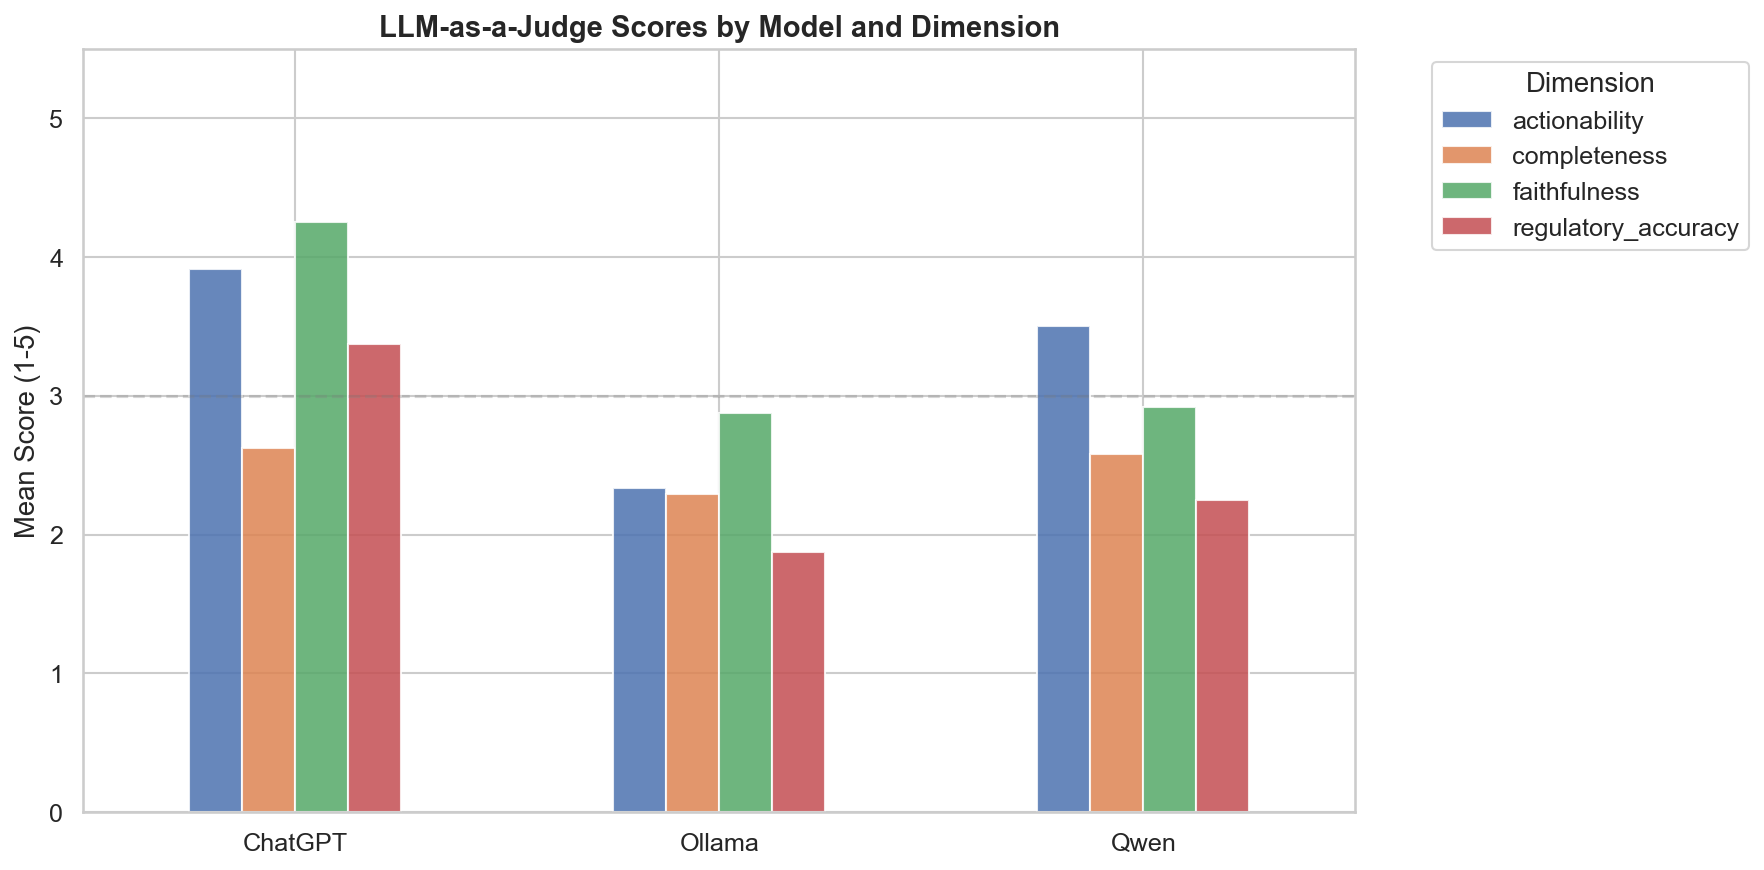

  Saved: ..\out\judge_results\judge_scores_by_model.png


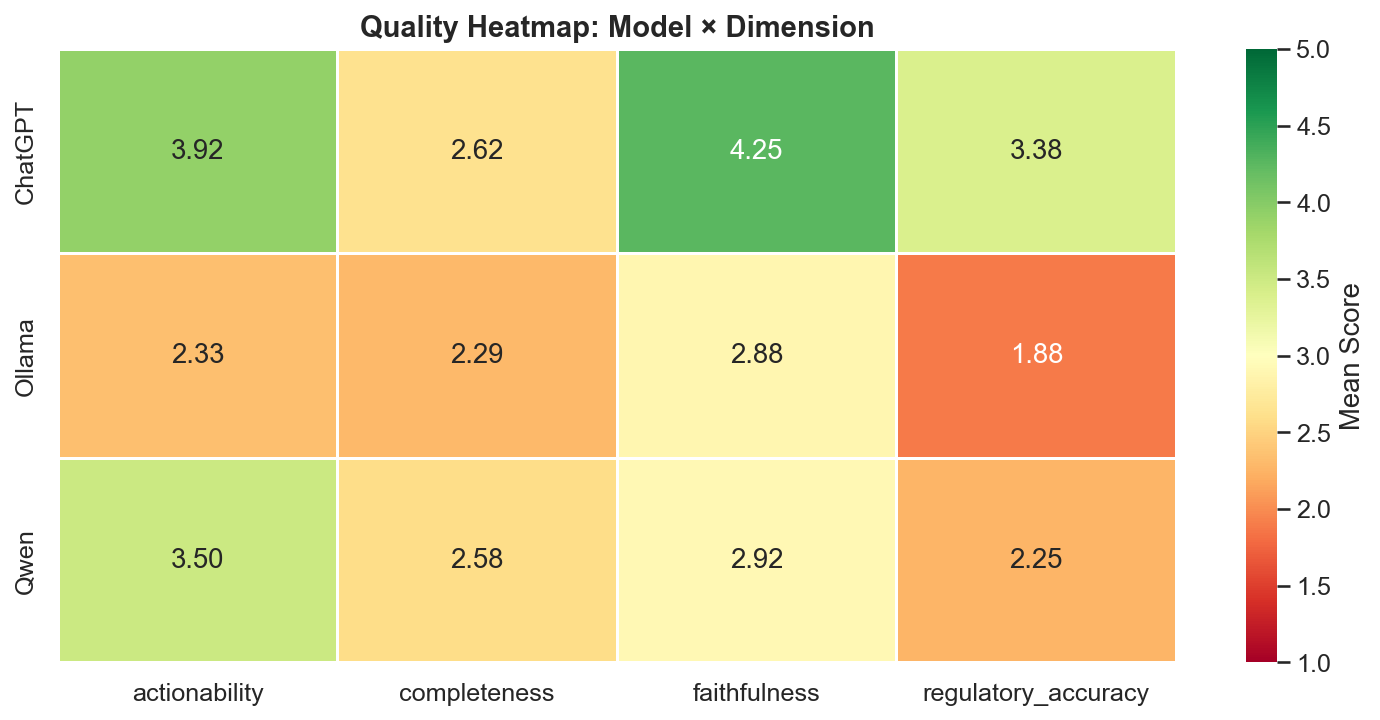

  Saved: ..\out\judge_results\judge_heatmap.png


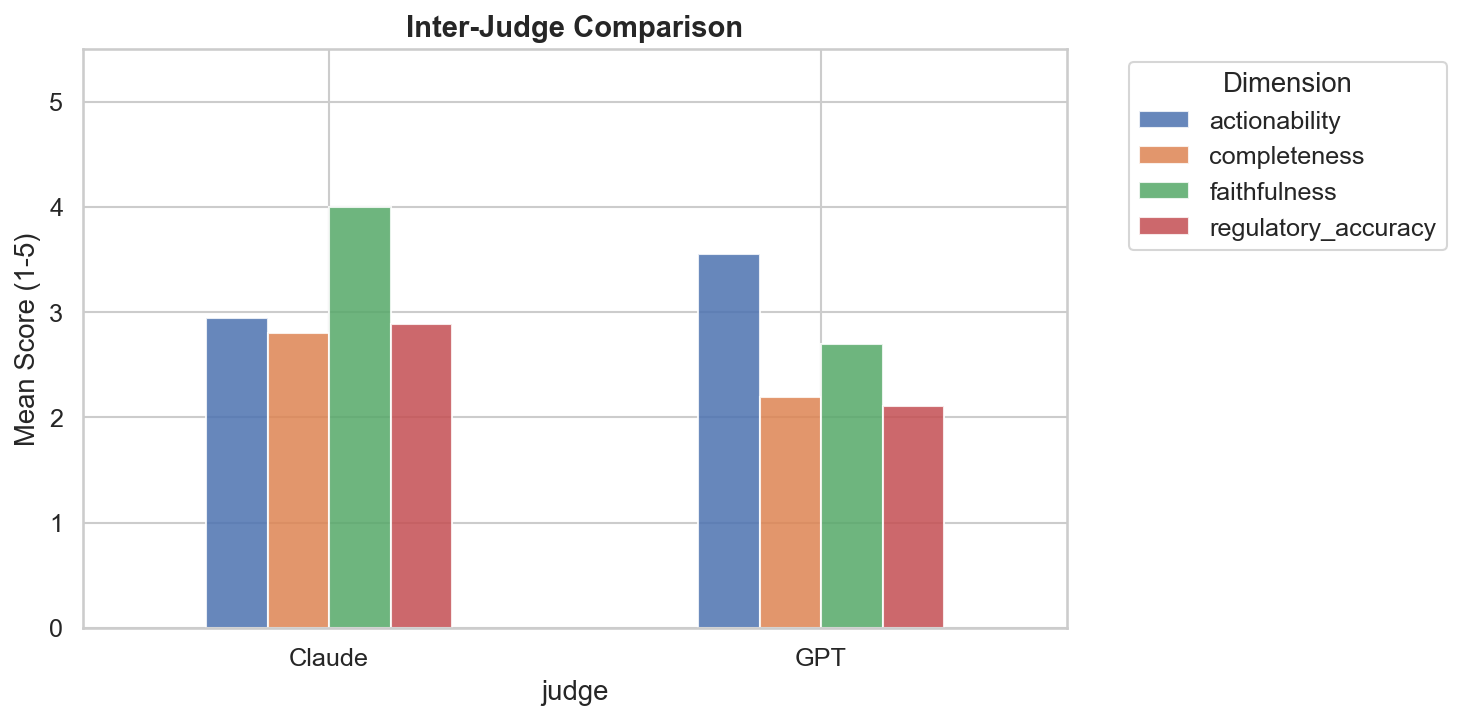

  Saved: ..\out\judge_results\inter_judge_comparison.png


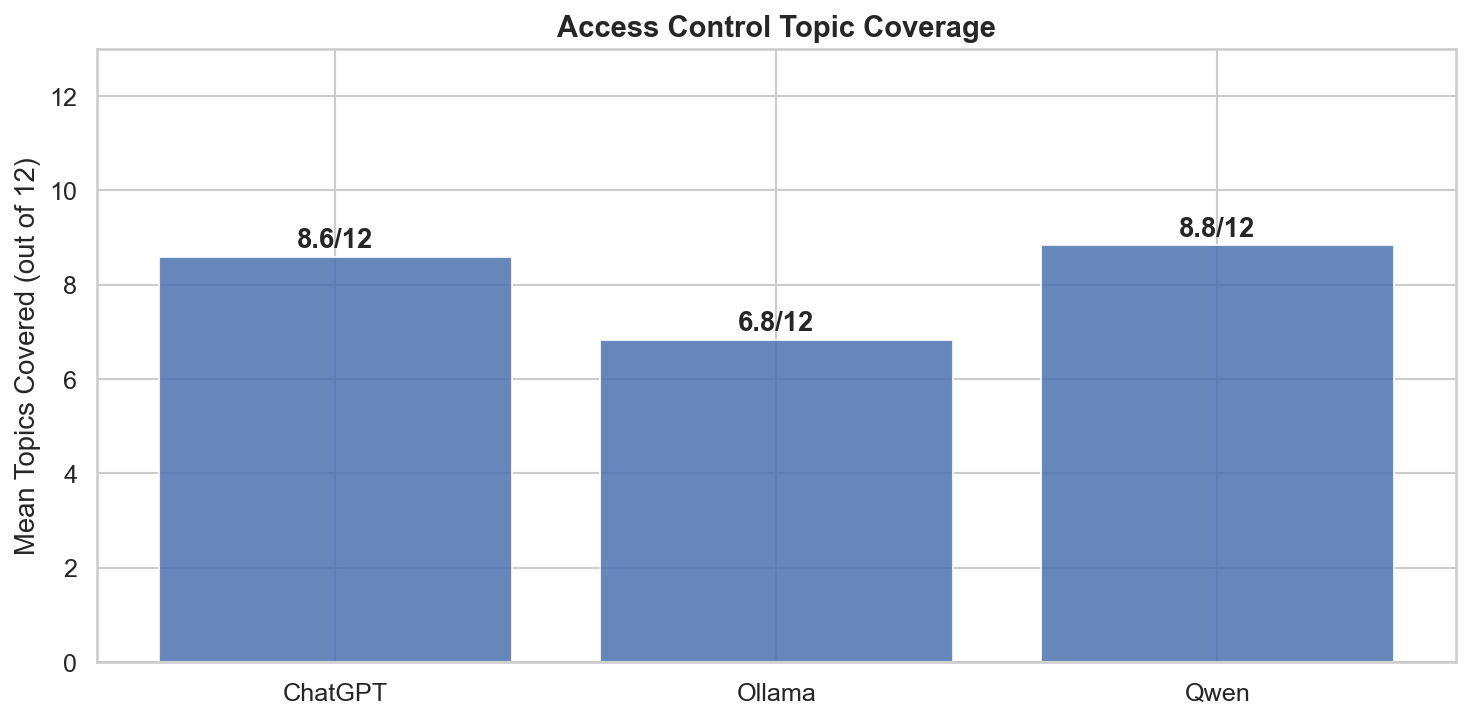

  Saved: ..\out\judge_results\access_control_coverage.png


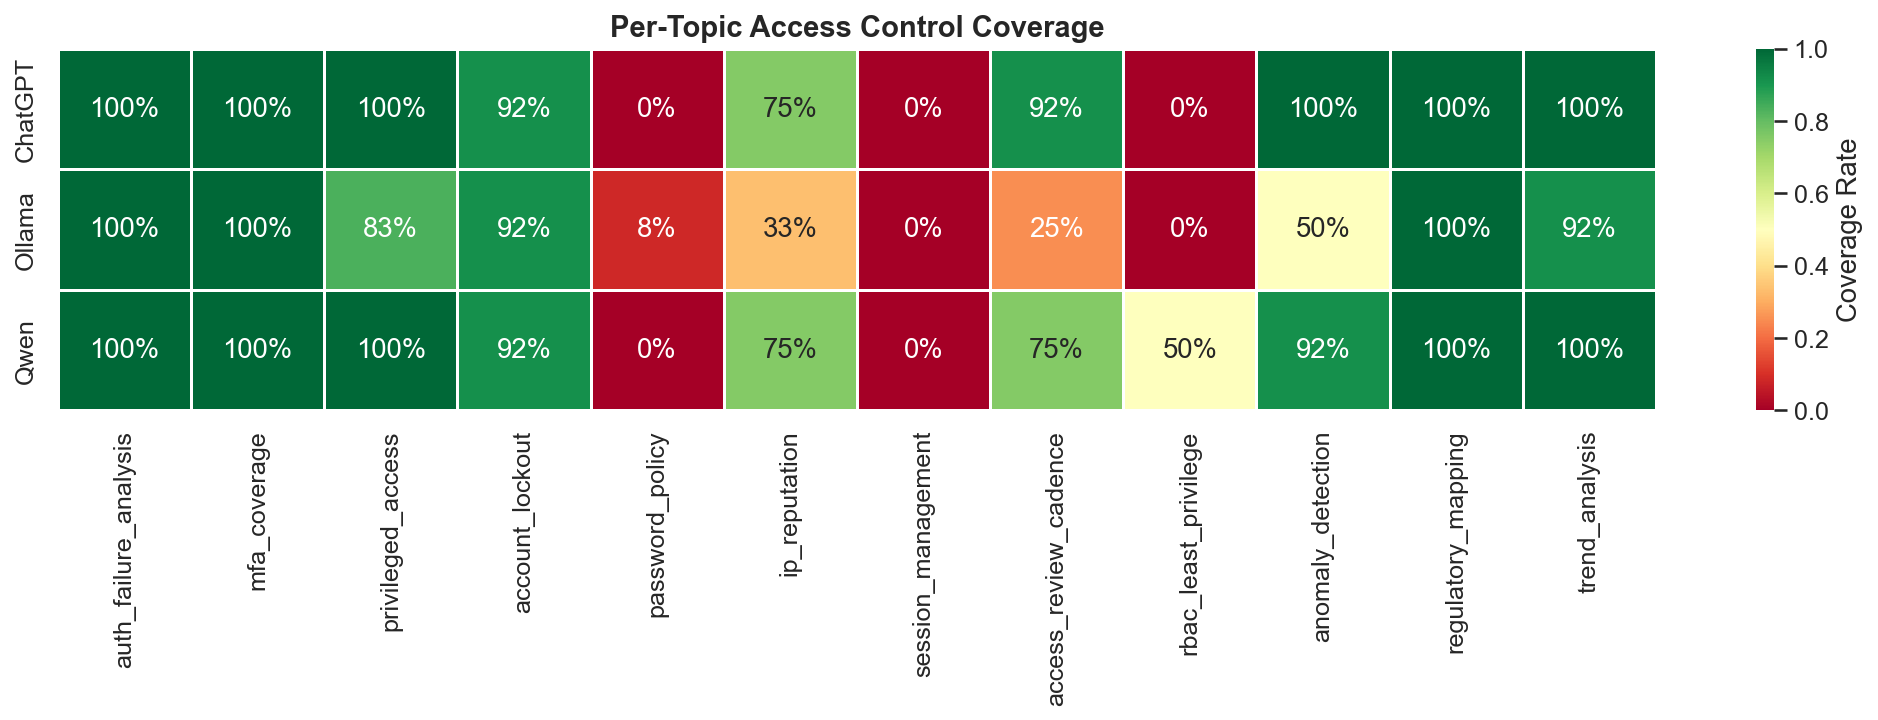

  Saved: ..\out\judge_results\topic_coverage_heatmap.png


In [ ]:
# Visualisations for the Paper

def plot_results(judge_results: pd.DataFrame, coverage_df: pd.DataFrame, save_dir: Path) -> None:
    """Generate publication-quality plots."""
    save_dir.mkdir(parents=True, exist_ok=True)
    
    valid = judge_results[judge_results["score"].notna()].copy()
    valid["score"] = valid["score"].astype(int)
    
    if len(valid) == 0:
        print("No valid results to plot.")
        return
    
    # Plot 1: Mean scores by model and dimension
    fig, ax = plt.subplots(figsize=(12, 6))
    pivot = valid.groupby(["folder", "dimension"])["score"].mean().unstack()
    pivot.plot(kind="bar", ax=ax, alpha=0.85, edgecolor="white")
    ax.set_ylabel("Mean Score (1-5)")
    ax.set_xlabel("")
    ax.set_title("LLM-as-a-Judge Scores by Model and Dimension", fontsize=14, fontweight="bold")
    ax.set_ylim(0, 5.5)
    ax.legend(title="Dimension", bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.axhline(y=3, color="gray", linestyle="--", alpha=0.3, label="Acceptable threshold")
    plt.xticks(rotation=0)
    plt.tight_layout()
    fig.savefig(save_dir / "judge_scores_by_model.png", dpi=300, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {save_dir / 'judge_scores_by_model.png'}")
    
    # Plot 2: Score distribution heatmap
    fig, ax = plt.subplots(figsize=(10, 5))
    heatmap_data = valid.groupby(["folder", "dimension"])["score"].mean().unstack()
    sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="RdYlGn", vmin=1, vmax=5,
                ax=ax, linewidths=0.5, cbar_kws={"label": "Mean Score"})
    ax.set_title("Quality Heatmap: Model × Dimension", fontsize=14, fontweight="bold")
    ax.set_ylabel("")
    ax.set_xlabel("")
    plt.tight_layout()
    fig.savefig(save_dir / "judge_heatmap.png", dpi=300, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {save_dir / 'judge_heatmap.png'}")
    
    # Plot 3: Judge agreement (if multiple judges)
    if valid["judge"].nunique() > 1:
        fig, ax = plt.subplots(figsize=(10, 5))
        judge_pivot = valid.groupby(["judge", "dimension"])["score"].mean().unstack()
        judge_pivot.plot(kind="bar", ax=ax, alpha=0.85, edgecolor="white")
        ax.set_ylabel("Mean Score (1-5)")
        ax.set_title("Inter-Judge Comparison", fontsize=14, fontweight="bold")
        ax.set_ylim(0, 5.5)
        ax.legend(title="Dimension", bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.xticks(rotation=0)
        plt.tight_layout()
        fig.savefig(save_dir / "inter_judge_comparison.png", dpi=300, bbox_inches="tight")
        plt.show()
        print(f"  Saved: {save_dir / 'inter_judge_comparison.png'}")
    
    # Plot 4: Access Control Coverage
    if len(coverage_df) > 0 and coverage_df["coverage_count"].notna().any():
        fig, ax = plt.subplots(figsize=(10, 5))
        cov_data = coverage_df.groupby("folder")["coverage_count"].mean()
        n_topics = len(ACCESS_CONTROL_TOPICS)
        bars = ax.bar(cov_data.index, cov_data.values, alpha=0.85, edgecolor="white")
        ax.set_ylabel(f"Mean Topics Covered (out of {n_topics})")
        ax.set_title("Access Control Topic Coverage", fontsize=14, fontweight="bold")
        ax.set_ylim(0, n_topics + 1)
        for bar, val in zip(bars, cov_data.values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                    f"{val:.1f}/{n_topics}", ha="center", fontweight="bold")
        plt.tight_layout()
        fig.savefig(save_dir / "access_control_coverage.png", dpi=300, bbox_inches="tight")
        plt.show()
        print(f"  Saved: {save_dir / 'access_control_coverage.png'}")
        
        # Plot 5: Per-topic heatmap
        topic_cols = [c for c in coverage_df.columns if c.startswith("topic_")]
        if topic_cols:
            fig, ax = plt.subplots(figsize=(14, 5))
            topic_data = coverage_df.groupby("folder")[topic_cols].mean()
            topic_data.columns = [c.replace("topic_", "") for c in topic_data.columns]
            sns.heatmap(topic_data, annot=True, fmt=".0%", cmap="RdYlGn", vmin=0, vmax=1,
                        ax=ax, linewidths=0.5, cbar_kws={"label": "Coverage Rate"})
            ax.set_title("Per-Topic Access Control Coverage", fontsize=14, fontweight="bold")
            ax.set_ylabel("")
            plt.tight_layout()
            fig.savefig(save_dir / "topic_coverage_heatmap.png", dpi=300, bbox_inches="tight")
            plt.show()
            print(f"  Saved: {save_dir / 'topic_coverage_heatmap.png'}")


if len(judge_results) > 0:
    plot_results(judge_results, coverage_df, RESULTS_DIR)

In [ ]:
# Export Final Summary Table for the Paper

def export_paper_table(judge_results: pd.DataFrame, coverage_df: pd.DataFrame, save_dir: Path):
    """Create the final comparison table combining all quality metrics."""
    valid = judge_results[judge_results["score"].notna()].copy()
    valid["score"] = valid["score"].astype(int)
    
    rows = []
    for folder in valid["folder"].unique():
        f_data = valid[valid["folder"] == folder]
        row = {"Model": folder}
        
        for dim in valid["dimension"].unique():
            dim_scores = f_data[f_data["dimension"] == dim]["score"]
            row[f"{dim} (mean)"] = round(dim_scores.mean(), 2) if len(dim_scores) > 0 else None
            row[f"{dim} (std)"] = round(dim_scores.std(), 2) if len(dim_scores) > 1 else None
        
        # Overall quality score
        row["Overall Quality"] = round(f_data["score"].mean(), 2)
        
        # Coverage
        if len(coverage_df) > 0:
            cov = coverage_df[coverage_df["folder"] == folder]["coverage_count"]
            row["NIS2 Coverage (mean)"] = round(cov.mean(), 1) if len(cov) > 0 else None
        
        rows.append(row)
    
    summary = pd.DataFrame(rows)
    summary.to_csv(save_dir / "paper_quality_table.csv", index=False)
    
    print("\n" + "="*80)
    print("FINAL QUALITY COMPARISON TABLE (for paper)")
    print("="*80)
    print(summary.to_string(index=False))
    print(f"\nSaved to: {save_dir / 'paper_quality_table.csv'}")
    
    return summary


if len(judge_results) > 0:
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    paper_table = export_paper_table(judge_results, coverage_df, RESULTS_DIR)

print("\n\nDone. All results are in:", RESULTS_DIR.resolve())


FINAL QUALITY COMPARISON TABLE (for paper)
  Model  regulatory_accuracy (mean)  regulatory_accuracy (std)  completeness (mean)  completeness (std)  faithfulness (mean)  faithfulness (std)  actionability (mean)  actionability (std)  Overall Quality  NIS2 Coverage (mean)
ChatGPT                        3.38                       0.92                 2.62                0.49                 4.25                0.79                  3.92                 0.28             3.54                   8.6
 Ollama                        1.88                       0.54                 2.29                0.46                 2.88                0.85                  2.33                 0.48             2.34                   6.8
   Qwen                        2.25                       0.53                 2.58                0.50                 2.92                0.88                  3.50                 0.51             2.81                   8.8

Saved to: ..\out\judge_results\paper_quality_ta